In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [10]:
import pandas as pd
from google.colab import drive

# 1. Google Driveをマウント（ポップアップが出て許可を求められます）
drive.mount('/content/drive')

# 2. データ定義
data = {
    "filename": [f"pointcloud_{i:03d}.csv" for i in range(1, 13)],
    "feature_1": [1.24, 0.88, 1.52, 0.95, 1.10, 1.30, 0.92, 1.45, 1.05, 1.18, 0.85, 1.60],
    "feature_2": [0.55, 0.71, 0.40, 0.66, 0.58, 0.45, 0.68, 0.42, 0.60, 0.52, 0.75, 0.35],
    "feature_3": [3.10, 2.95, 3.55, 3.02, 3.20, 3.40, 2.98, 3.50, 3.15, 3.25, 2.85, 3.65],
    "feature_4": [0.92, 1.15, 0.81, 1.04, 0.99, 0.88, 1.10, 0.85, 1.00, 0.95, 1.20, 0.75],
    "target_value": [15.4, 12.1, 18.2, 13.5, 14.8, 16.5, 12.8, 17.6, 14.2, 15.0, 11.5, 19.1]
}

# 3. DataFrameを作成
df = pd.DataFrame(data)

# 4. 指定したGoogle Driveのパスに保存
save_path = "/content/drive/MyDrive/meta_data.csv"
df.to_csv(save_path, index=False)

print(f"ファイルが正常に保存されました: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ファイルが正常に保存されました: /content/drive/MyDrive/meta_data.csv


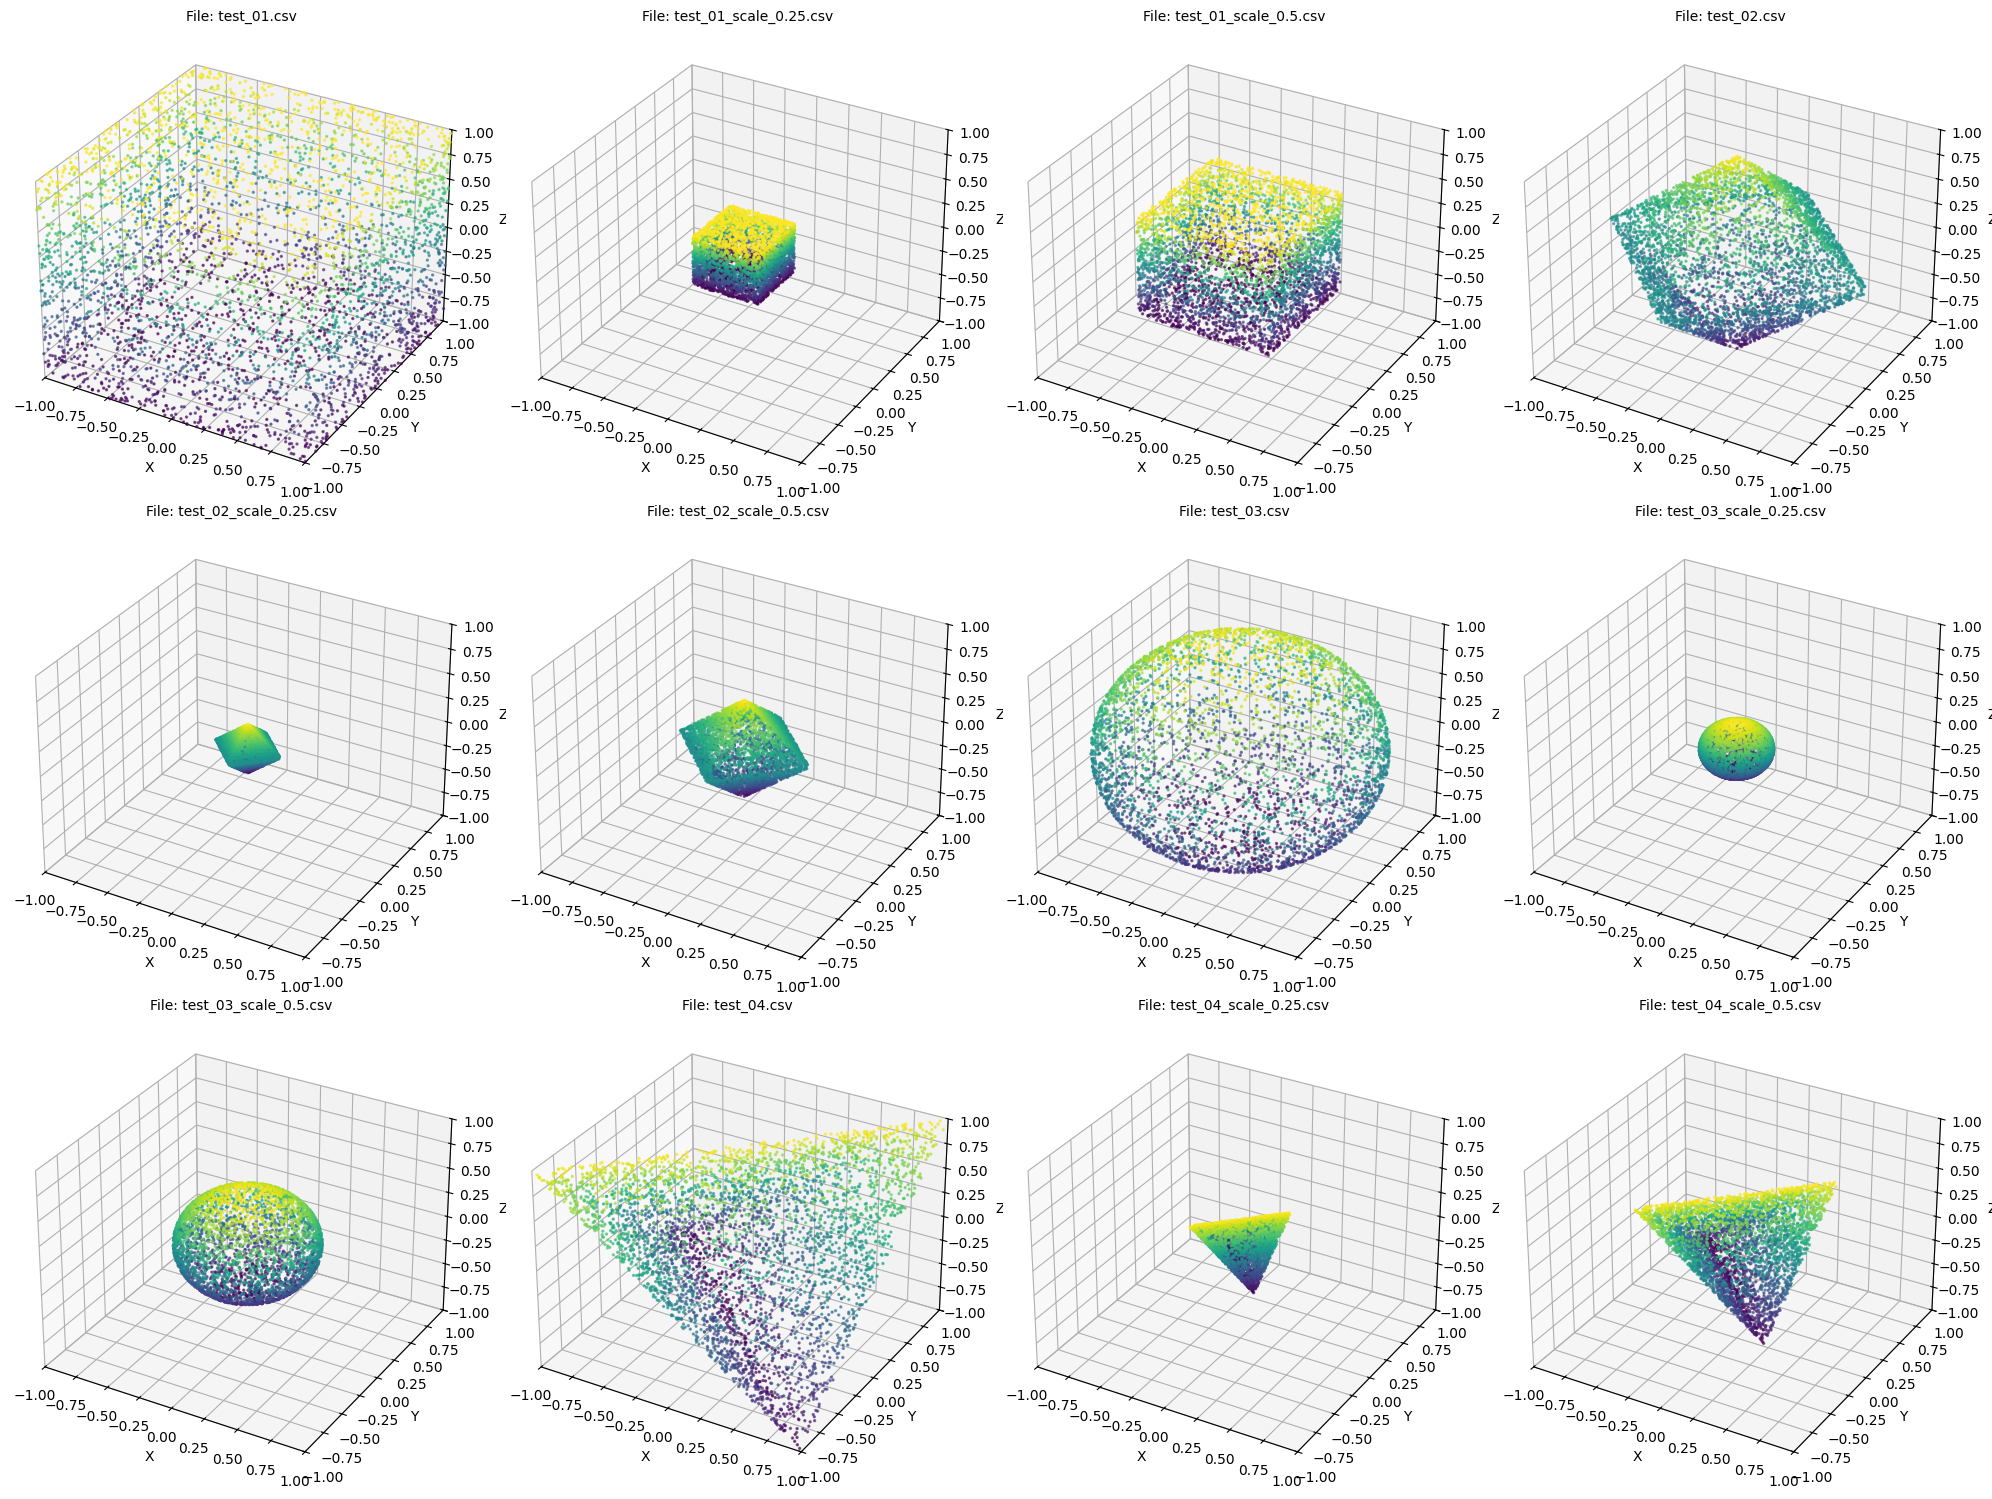

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. パスの設定
folder_path = "/content/drive/MyDrive/output_data_-1_1"  # フォルダパス

# 2. ファイルリストの取得（.csvのみ）
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
csv_files = sorted(csv_files)[:12]  # 最初の12個を選択するように変更

# 3. 可視化の準備 (12個配置するため、3行4列のグラフ領域を作成)
# 全体が収まるように少しサイズを大きく設定しています
fig = plt.figure(figsize=(20, 15))

for i, filename in enumerate(csv_files):
    # ファイルの読み込み
    file_full_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_full_path, header=None)
    
    # データが (N, 3) 形式であることを想定
    points = df.values
    
    # 4. サブプロットの追加 (3行4列の i+1 番目)
    ax = fig.add_subplot(3, 4, i + 1, projection='3d')
    
    # 散布図の描画 (c=points[:, 2] で高さに応じた色分け)
    sc = ax.scatter(points[:, 0], points[:, 1], points[:, 2], 
                    c=points[:, 2], cmap='viridis', s=2, alpha=0.6)
    
    # タイトルとラベル
    # ファイル名が長いと重なる可能性があるため、フォントサイズを少し小さめにしています
    ax.set_title(f"File: {filename}", fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    # ★ x, y, zの軸の表示範囲を -1 から 1 に固定
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])

# レイアウトの調整
plt.tight_layout()
plt.show()

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import os
import pandas as pd
import random
import numpy as np
import torch.nn.functional as F

# --- 1. エンコーダ・デコーダ・距離関数等の定義（変更なし） ---
class PointNetEncoder(nn.Module):
    def __init__(self, z_dim=256):
        super().__init__()
        self.z_dim = z_dim
        self.feature_extractor = nn.Sequential(
            self._conv_bn(3, 64),
            self._conv_bn(64, 128),
            self._conv_bn(128, 256),
            self._conv_bn(256, 512),
            self._conv_bn(512, 1024),
        )
        self.fc_mu = nn.Linear(1024, z_dim)
        self.fc_logvar = nn.Linear(1024, z_dim)

    def _conv_bn(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv1d(in_channels, out_channels, 1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(True)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.max(x, dim=2)[0] # (B, 1024)
        return self.fc_mu(x), self.fc_logvar(x)

class MLPDecoder(nn.Module):
    def __init__(self, z_dim=256, num_points=4096):
        super().__init__()
        self.num_points = num_points
        self.model = nn.Sequential(
            nn.Linear(z_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(True),
            nn.Linear(2048, num_points * 3),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.model(z)
        return x.view(-1, self.num_points, 3)

def chamfer_distance(p1, p2):
    p1_norm = torch.sum(p1**2, dim=2, keepdim=True) 
    p2_norm = torch.sum(p2**2, dim=2, keepdim=True).transpose(1, 2)
    dist_matrix = p1_norm + p2_norm - 2 * torch.bmm(p1, p2.transpose(1, 2))
    dist_matrix = torch.clamp(dist_matrix, min=0.0)
    dist_p1_p2 = torch.min(dist_matrix, dim=2)[0]
    dist_p2_p1 = torch.min(dist_matrix, dim=1)[0]
    return dist_p1_p2.sum(dim=1).mean() + dist_p2_p1.sum(dim=1).mean()

# --- モデルの変更: 回帰器の追加 ---
class PointCloudVAE(nn.Module):
    def __init__(self, z_dim=3, num_points=4096, num_ext_features=4):
        super().__init__()
        self.encoder = PointNetEncoder(z_dim)
        self.decoder = MLPDecoder(z_dim, num_points)
        
        # 追加: 重回帰分析用の線形予測層 (潜在変数3 + 外部変数4 = 入力7)
        self.regressor = nn.Linear(z_dim + num_ext_features, 1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, ext_features=None):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        
        pred_target = None
        if ext_features is not None:
            # 潜在変数と外部説明因子を結合して目的変数を予測
            reg_input = torch.cat([mu, ext_features], dim=1)
            pred_target = self.regressor(reg_input)
            
        return recon, mu, logvar, pred_target

In [5]:
# --- 2. カスタムデータセットの変更 ---
class PointCloudCSVDataset(Dataset):
    def __init__(self, folder_path, meta_csv_path, max_points=4096):
        self.points_list = []
        self.ext_features_list = []
        self.targets_list = []
        
        # 外部CSVの読み込み
        # 構成の仮定: 1列目がファイル名, 2〜5列目が説明因子, 6列目が目的変数
        meta_df = pd.read_csv(meta_csv_path)
        meta_dict = {}
        for _, row in meta_df.iterrows():
            filename = str(row.iloc[0])
            features = row.iloc[1:5].values.astype(np.float32) # 4つの説明因子
            target = np.array([row.iloc[5]]).astype(np.float32) # 目的変数
            meta_dict[filename] = (features, target)

        if not os.path.exists(folder_path):
            print(f"Warning: {folder_path} not found.")
            return

        csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

        for filename in csv_files:
            if filename not in meta_dict:
                continue # メタデータに対応するファイルがない場合はスキップ
                
            df = pd.read_csv(os.path.join(folder_path, filename), header=None, dtype=np.float32)
            pts = df.values
            if len(pts) >= max_points:
                indices = np.random.choice(len(pts), max_points, replace=False)
                self.points_list.append(torch.from_numpy(pts[indices]).t())
                
                # 対応する説明因子と目的変数を格納
                feats, target = meta_dict[filename]
                self.ext_features_list.append(torch.from_numpy(feats))
                self.targets_list.append(torch.from_numpy(target))
                
    def __len__(self):
        return len(self.points_list)

    def __getitem__(self, idx):
        return self.points_list[idx], self.ext_features_list[idx], self.targets_list[idx]

# --- 3. 学習マネージャーの変更 (R2ロスの追加) ---
class PointCloudTrainer:
    def __init__(self, model, lr=1e-4, device="cuda" if torch.cuda.is_available() else "cpu"):
        self.device = torch.device(device)
        self.model = model.to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == "cuda"))
        
    def train_epoch(self, dataloader, epoch, warmup_epochs, start_points=1024, max_points=4096, gamma=1.0):
        self.model.train()
        total_loss, total_recon, total_kl, total_r2_loss = 0, 0, 0, 0
        
        alpha = min(1.0, epoch / max(1, warmup_epochs))
        curr_points = int(start_points + (max_points - start_points) * alpha)
        curr_points = (curr_points // 32) * 32 
        
        start_beta = 0.01
        max_beta = 1.0
        beta = start_beta + (max_beta - start_beta) * alpha
        
        for batch in dataloader:
            points, ext_features, targets = batch
            points = points.to(self.device)
            ext_features = ext_features.to(self.device)
            targets = targets.to(self.device)
            
            self.optimizer.zero_grad()
            
            with torch.cuda.amp.autocast(enabled=(self.device.type == "cuda")):
                # モデル出力に外部変数を渡し、回帰予測値も取得
                reconstructed, mu, logvar, pred_targets = self.model(points, ext_features)
                
                target_pts = points.transpose(1, 2)[:, :curr_points, :]
                pred_pts = reconstructed[:, :curr_points, :]
                
                recon_loss = chamfer_distance(pred_pts, target_pts)
                kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
                
                # --- 重回帰分析の R2 を正則化として計算 ---
                # R2 = 1 - (残差平方和 / 全変動)
                ss_res = torch.sum((targets - pred_targets) ** 2)
                ss_tot = torch.sum((targets - torch.mean(targets)) ** 2)
                
                # ゼロ除算回避のための微小値(1e-8)を追加
                r2 = 1 - ss_res / (ss_tot + 1e-8)
                
                # R2は最大化したい(1に近づけたい)ため、損失としては 1 - R2 を使用
                r2_loss = 1.0 - r2 
                
                # トータルロス (gamma で R2ロスの影響力を調整)
                loss = 1.0 * recon_loss + 5.0 * beta * kl_loss + gamma * r2_loss
            
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
            
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            total_r2_loss += r2_loss.item()
            
        n_batches = len(dataloader)
        return total_loss / n_batches, total_recon / n_batches, total_kl / n_batches, total_r2_loss / n_batches, beta, curr_points

# --- 4. メイン実行 ---
# 設定
meta_csv_path = "/content/drive/MyDrive/meta_data/meta_data_update.csv"  # フォルダパス
z_dim = 3
num_points = 4096
batch_size = 12  # ★重要: 重回帰を行うため、4から16以上に変更してください
num_epochs = 2000
lr = 5e-5
warmup_epochs = 1500
gamma = 10.0 # R2正則化の重み（必要に応じて調整）

# 準備
# folder_path = "your_csv_folder"
# meta_csv_path = "your_meta_data.csv" # 外部CSVのパス
dataset = PointCloudCSVDataset(folder_path, meta_csv_path, max_points=num_points)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True) # バッチサイズ変動を防ぐためdrop_last=True推奨

vae = PointCloudVAE(z_dim=z_dim, num_points=num_points, num_ext_features=4)
trainer = PointCloudTrainer(vae, lr=lr)

print(f"Starting Warmup Training: 0 -> {warmup_epochs} epochs")

for epoch in range(num_epochs):
    avg_loss, avg_recon, avg_kl, avg_r2_loss, current_beta, curr_p = trainer.train_epoch(
        dataloader, epoch, warmup_epochs, start_points=256, max_points=num_points, gamma=gamma
    )
    
    if (epoch + 1) == 1 or (epoch + 1) % 500 == 0:
        status = "WARMUP" if epoch < warmup_epochs else "STABLE"
        # R2スコアは 1 - R2_loss で概算確認可能
        approx_r2 = 1.0 - avg_r2_loss
        print(f"[{status}] Epoch [{epoch+1:>4}/{num_epochs}] Pts: {curr_p:>4} | "
              f"Loss: {avg_loss:8.4f} | Recon: {avg_recon:8.4f} | "
              f"KL: {avg_kl:8.4f} | R2_Score: {approx_r2:6.4f}")

/tmp/ipython-input-150306569.py:51: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == "cuda"))
/tmp/ipython-input-150306569.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device.type == "cuda")):


Starting Warmup Training: 0 -> 1500 epochs
[WARMUP] Epoch [   1/2000] Pts:  256 | Loss: 484.0536 | Recon:  44.0194 | KL:   5.3646 | R2_Score: -42.9766
[WARMUP] Epoch [ 500/2000] Pts: 1504 | Loss: 356.1271 | Recon:   6.9736 | KL:  46.7697 | R2_Score: -25.9799
[WARMUP] Epoch [1000/2000] Pts: 2784 | Loss: 382.5621 | Recon:   8.3286 | KL:  17.5910 | R2_Score: -30.5362
[WARMUP] Epoch [1500/2000] Pts: 4064 | Loss: 402.0805 | Recon:   9.6156 | KL:  12.1149 | R2_Score: -32.1931
[STABLE] Epoch [2000/2000] Pts: 4096 | Loss: 389.7574 | Recon:   7.7093 | KL:  14.3145 | R2_Score: -30.0476


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_trained_reconstructions(vae, dataloader):
    """
    学習データから得られた実際の潜在変数を使って再構成を表示する
    """
    vae.eval()
    device = next(vae.parameters()).device
    
    # 1. データの取得（1バッチ分）
    with torch.no_grad():
        batch = next(iter(dataloader)) # (B, 3, N)
        batch = batch.to(device)
        
        # エンコーダで実際の潜在変数(mu)を取得
        mu, _ = vae.encoder(batch)
        # そのmuを使ってデコード（再構成）
        reconstructed_points = vae.decoder(mu).cpu().numpy()
        
    num_samples = reconstructed_points.shape[0]
    mu_np = mu.cpu().numpy()

    # グリッドのサイズを計算 (例: 4サンプルなら 2x2)
    cols = int(np.ceil(np.sqrt(num_samples)))
    rows = int(np.ceil(num_samples / cols))

    fig = plt.figure(figsize=(cols * 5, rows * 5))
    
    for i in range(num_samples):
        ax = fig.add_subplot(rows, cols, i + 1, projection="3d")
        points = reconstructed_points[i]
        
        # 3D散布図
        # c=points[:, 2] で高さ（Z軸）に応じて色付け
        sc = ax.scatter(points[:, 0], points[:, 1], points[:, 2], 
                        s=2, c=points[:, 2], cmap='viridis', alpha=0.6)
        
        # タイトルにこのデータの潜在変数の値を表示
        mu_str = ", ".join([f"{val:.2f}" for val in mu_np[i]])
        ax.set_title(f"Reconstruction {i+1}\nLatent (mu): [{mu_str}]", fontsize=10)
        
        # 軸の範囲設定（データが-1〜1の範囲なので少し広めに設定）
        ax.set_xlim([-1.1, 1.1])
        ax.set_ylim([-1.1, 1.1])
        ax.set_zlim([-1.1, 1.1])

# メモリを -1, 0, 1 に設定
        ticks = [-1.0, 0.0, 1.0]
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_zticks(ticks)

        # 軸のメモリを消す（見た目スッキリ）
#        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

    plt.tight_layout()
    plt.show()

# --- 実行 ---
# 学習が終わった後に呼び出してください
visualize_trained_reconstructions(vae, dataloader)

AttributeError: 'list' object has no attribute 'to'

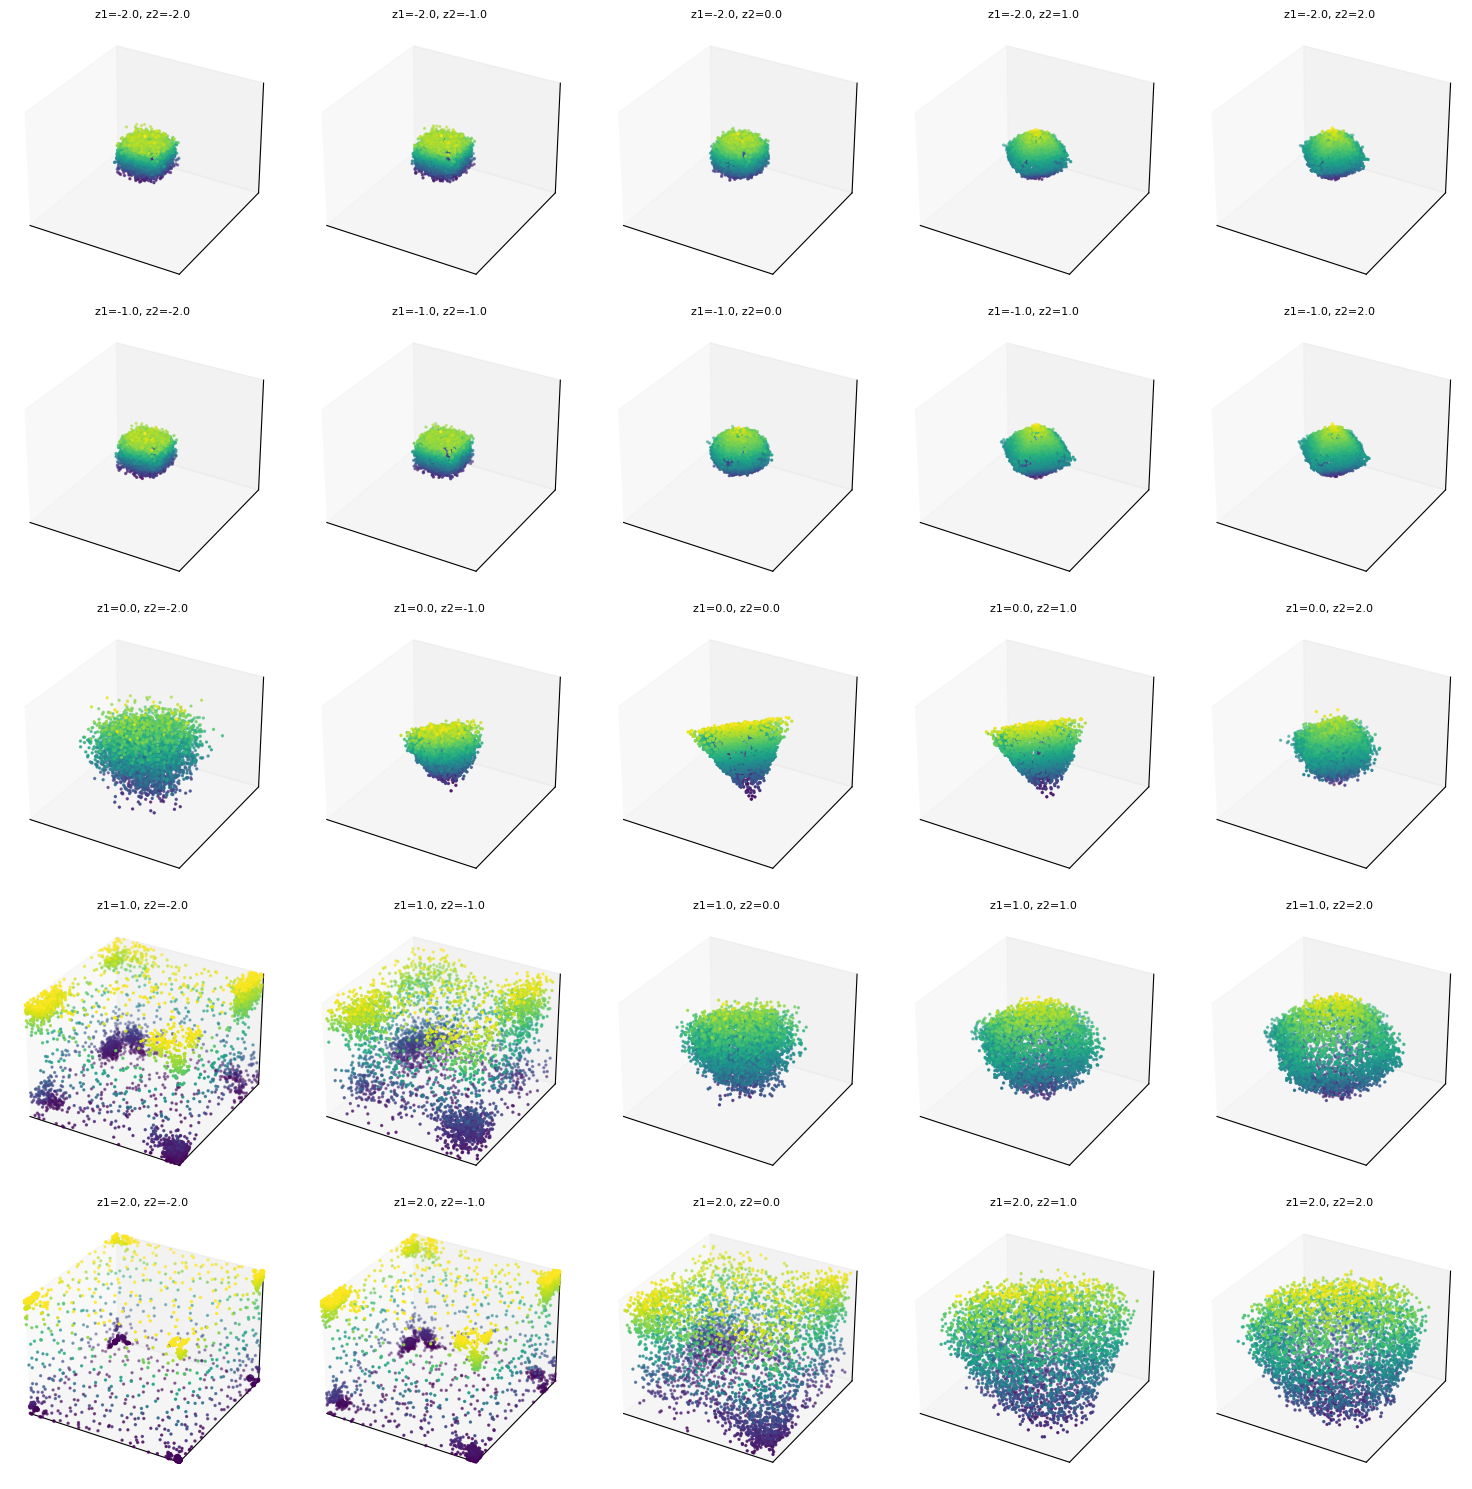

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_latent_space(decoder, z_dim, z1_range, z2_range, z1_steps, z2_steps):
    # モデルが現在どのデバイスにあるか取得
    device = next(decoder.parameters()).device
    
    z1_values = np.linspace(z1_range[0], z1_range[1], z1_steps)
    z2_values = np.linspace(z2_range[0], z2_range[1], z2_steps)

    fig = plt.figure(figsize=(15, 15))
    plot_index = 1
    
    for z1 in z1_values:
        for z2 in z2_values:
            # デバイスを指定してテンソルを作成
            z = torch.zeros((1, z_dim), dtype=torch.float32).to(device)
            z[0, 0] = z1
            z[0, 1] = z2

            with torch.no_grad():
                generated_points = decoder(z).squeeze().cpu().numpy()

            ax = fig.add_subplot(z1_steps, z2_steps, plot_index, projection="3d")
            sc = ax.scatter(generated_points[:, 0], generated_points[:, 1], generated_points[:, 2], 
                            s=2, c=generated_points[:, 2], cmap='viridis')

            ax.set_title(f"z1={z1:.1f}, z2={z2:.1f}", fontsize=8)
            
            # 軸の範囲（点群が0〜1の範囲に正規化されている場合）
            ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
            ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

            plot_index += 1

    plt.tight_layout()
    plt.show()

# 実行
#visualize_latent_space(decoder, z_dim=3, 
#                       z1_range=[-2, 2], z2_range=[-2, 2], 
#                       z1_steps=5, z2_steps=5)


# 'decoder' ではなく 'vae.decoder' を渡す
# また、推論モード（eval）に設定することを推奨します
vae.eval() 

visualize_latent_space(
    decoder=vae.decoder,      # ここを修正
    z_dim=3, 
    z1_range=[-2, 2], 
    z2_range=[-2, 2], 
    z1_steps=5, 
    z2_steps=5
)